In [1]:
import sys
import os
import datetime 

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# The GeographicLib is likely more accurate than geooack.
# Geographiclib - https://geographiclib.sourceforge.io/Python/2.0/
# mamba install conda-forge::geographiclib
from geographiclib.geodesic import Geodesic
geod = Geodesic.WGS84

import ionolib
import gnss_dtec_map
%matplotlib inline

# IRI Simulation

In [2]:
# Set Default Values
time    = datetime.datetime(2018,12,15,20)
time_0  = time
# engine  = 'PyIRI'  # Victoria Forsythe's PyIRI (https://github.com/victoriyaforsythe/PyIRI)
engine  = 'iri2016' # Michael Hirsch's IRI2016 Python Wrapper (https://github.com/space-physics/iri2016)

output_dir  = os.path.join('output',engine)
profile_dir = os.path.join(output_dir,'profiles')
ionolib.gen_lib.prep_dirs({0:profile_dir},php=False)

map_dir     = os.path.join(output_dir,'maps')
ionolib.gen_lib.prep_dirs({0:map_dir},php=False)

In [3]:
kw_args             = {}
kw_args['engine']   = engine
kw_args['sDate']    = time
kw_args['eDate']    = time
kw_args['hgt_0']    =    0.0
kw_args['hgt_1']    =  600.0
kw_args['hgt_step'] =    3.0

kw_args['lat_0']    =   20.0
kw_args['lat_1']    =   80.0
kw_args['lon_0']    = -130.0
kw_args['lon_1']    =  -50.0
kw_args['lat_step'] =    0.50
kw_args['lon_step'] =    0.50

#kw_args['lat_0']    =   -90.
#kw_args['lat_1']    =    90.
#kw_args['lon_0']    = -180.0
#kw_args['lon_1']    =  180.0

print('Generating 3d Ionosphere...')
iono = ionolib.iono_grid.iono_3d(**kw_args)

print('Adding in TID...')
advance_minutes = (time - time_0).total_seconds()/60.
wave_list = []
src_lat   = 78
src_lon   = -75
amplitude = 25
lambda_h  = 1000
T_minutes = 120
wave_list.append(dict(src_lat=src_lat,src_lon=src_lon,amplitude=amplitude,lambda_h=lambda_h,T_minutes=T_minutes,advance_minutes=advance_minutes))
iono.generate_wave(wave_list)

Generating 3d Ionosphere...
Adding in TID...


In [4]:
iono.dates

[datetime.datetime(2018, 12, 15, 20, 0)]

In [5]:
# World
xlim    = (-180,180)
ylim    = (-90,90)

# # CONUS
# xlim    = (-130,-56)
# ylim    = (20,55)

# # CONUS + Canada
# xlim    = (-130,-56)
# ylim    = (20,80)

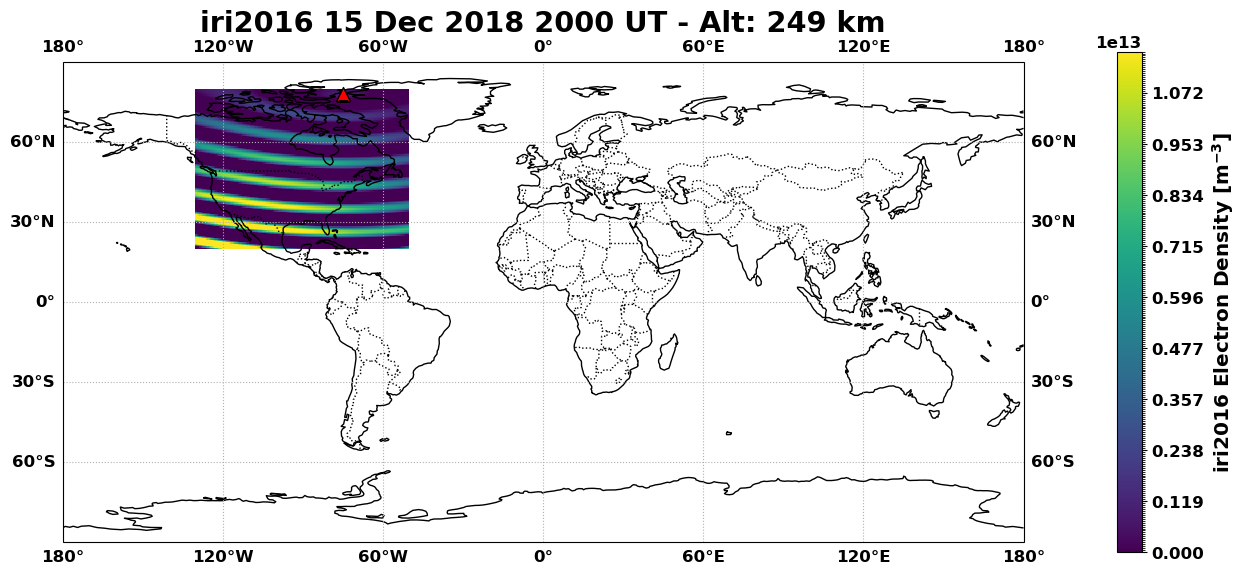

In [6]:
alt=250.
figsize=(16,10)

ds      = iono.iri_dataset
edens   = ds['electron_density'].values
lats    = ds['lat'].values
lons    = ds['lon'].values
alts    = ds['alt'].values
dates   = list(map(pd.to_datetime,ds['date'].values))

alt_inx = np.argmin(np.abs(alts-alt))

scale,ticks,cmap = ionolib.iono_grid.calculate_scale(edens[:,:,:,alt_inx])
bounds      = np.linspace(scale[0],scale[1],256)
norm        = matplotlib.colors.BoundaryNorm(bounds,cmap.N)

dInx = 0
date = iono.dates[dInx]

this_edens  = edens[dInx,:,:]

fig     = plt.figure(figsize=figsize)
ax      = fig.add_subplot(111,projection=ccrs.PlateCarree())

ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.set_title('')
ax.gridlines(draw_labels=True)

LONS, LATS  = np.meshgrid(lons,lats)
data        = this_edens[:,:,alt_inx]
pcoll       = ax.pcolormesh(LONS,LATS,data,cmap=cmap,norm=norm)

# Plot Wave Source Locations
if hasattr(iono,'wave_list'):
    for wave in iono.wave_list:
        wlat    = wave['src_lat']
        wlon    = wave['src_lon']
        ax.scatter(wlon,wlat,marker='^',s=100,zorder=110,ec='k',fc='red')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

cbar_label  = iono.engine + r' Electron Density [m$^{-3}$]'
cbar        = fig.colorbar(pcoll,orientation='vertical',shrink=0.65,pad=0.075,ticks=ticks)
cbar.set_label(cbar_label,fontdict={'weight':'bold','size':'large'})

# Plot Title
txt = []
txt.append('{!s} {!s} - Alt: {:.0f} km'.format(iono.engine,
                                               date.strftime('%d %b %Y %H%M UT'),float(alts[alt_inx])))
ax.set_title('\n'.join(txt),fontdict={'weight':'bold','size':'xx-large'})
plt.show()

In [7]:
mc_paths_csv = '20181215_14000-14350kHz_montePaths.csv'
mc_df = pd.read_csv(mc_paths_csv,comment='#')

tf = np.logical_or(mc_df['azm'] >= 355, mc_df['azm'] <= 5)
mc_df = mc_df[tf]

mc_df = mc_df.sort_values('pthlen')
mc_df['tx_rx'] = mc_df['call_sign_tx'] + '_' + mc_df['call_sign_rx']
mc_df[['tx_rx','pthlen','azm']]

,tx_rx,pthlen,azm
1858,N8OFP_N8OFP,0.000000,0.000000
2061,SA5SSA_KB2SYD,119.274448,4.004009
942,KC1CIL_WA1TFV,148.113041,358.019245
1648,N4EEB_AB4UF,185.502005,357.542882
406,K2IZV_VE7DJE,198.677206,357.813391
2863,WD4CNO_WD4AH,210.588983,359.234229
185,AF4T_K8FER,232.119853,3.586996
1239,KG5VDC_KG5RMJ,243.641237,2.108354
504,K4AMC_KC9REX,315.553222,1.282489
571,K4ZLT_N8FL,322.194801,4.196516


In [8]:
tx_rx = 'K0DEW_KD0MPZ'

tx,rx = tx_rx.split('_')
tx_rx_inx = np.where(np.logical_and(mc_df['call_sign_rx']==rx,mc_df['call_sign_tx']==tx))[0][0]
tx_rx_row = mc_df.iloc[tx_rx_inx]

In [9]:
tx_rx_row

call_sign_tx           K0DEW
txlat                37.6688
txlon               -92.6625
call_sign_rx          KD0MPZ
rxlat                46.6458
rxlon                -92.875
pthlen            998.349442
latcen             42.157349
loncen            -92.761199
azm               359.065185
tx_rx           K0DEW_KD0MPZ
Name: 294, dtype: object

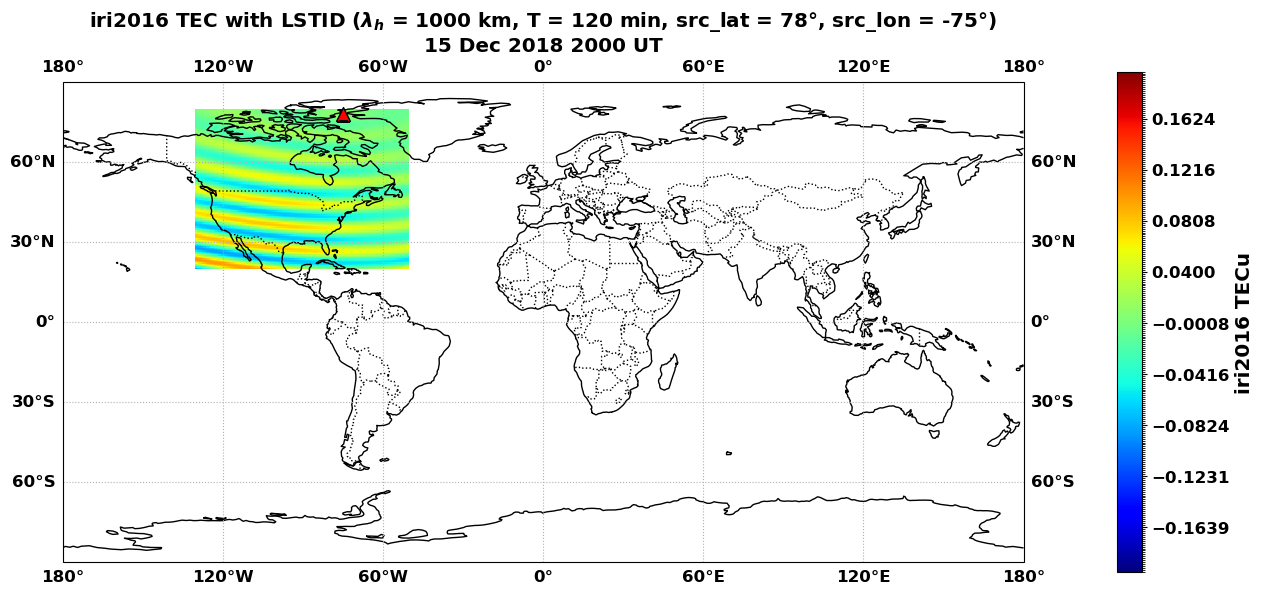

In [10]:
tx_rx = None

alt=250.
figsize=(16,10)

ds      = iono.iri_dataset
edens   = ds['electron_density'].values
lats    = ds['lat'].values
lons    = ds['lon'].values
alts    = ds['alt'].values
dates   = list(map(pd.to_datetime,ds['date'].values))

scale   = (-0.2,0.2)
ticks   = None
cmap    = matplotlib.cm.jet

bounds      = np.linspace(scale[0],scale[1],256)
norm        = matplotlib.colors.BoundaryNorm(bounds,cmap.N)

dInx = 0
date = iono.dates[dInx]

this_edens  = edens[dInx,:,:]

fig     = plt.figure(figsize=figsize)
ax      = fig.add_subplot(111,projection=ccrs.PlateCarree())

ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.set_title('')
ax.gridlines(draw_labels=True)

LONS, LATS  = np.meshgrid(lons,lats)
# data        = this_edens[:,:,alt_inx]
this_TECu   = np.sum(this_edens,axis=2)/1e16
this_dTEC   = this_TECu - this_TECu.mean()
data        = this_dTEC
pcoll       = ax.pcolormesh(LONS,LATS,data,cmap=cmap,norm=norm)

# Plot Wave Source Locations
if hasattr(iono,'wave_list'):
    for wave in iono.wave_list:
        wlat    = wave['src_lat']
        wlon    = wave['src_lon']
        ax.scatter(wlon,wlat,marker='^',s=100,zorder=110,ec='k',fc='red')

if tx_rx is not None:
    tx,rx = tx_rx.split('_')
    # Plot Endpoints
    tx_call     = 'TX: '+tx_rx_row['call_sign_tx']
    tx_lat      = tx_rx_row['txlat']
    tx_lon      = tx_rx_row['txlon']

    rx_call     = 'RX: '+tx_rx_row['call_sign_rx']
    rx_lat      = tx_rx_row['rxlat']
    rx_lon      = tx_rx_row['rxlon']

    ax.scatter(tx_lon,tx_lat,marker='*',s=450,zorder=110,label=tx_call,ec='k',fc='red')
    ax.scatter(rx_lon,rx_lat,marker='*',s=450,zorder=110,label=rx_call,ec='k',fc='orange')
    fontdict = {'size':'x-large','weight':'bold'}
    # offset = 1.1
    # ax.text(tx_lon,tx_lat+offset,tx_call,fontdict=fontdict,ha='center')
    # ax.text(rx_lon,rx_lat+offset,rx_call,fontdict=fontdict,ha='center')

    # Plot Path
    # Determine the ranges and azimuth along the profile path.
    invl    = geod.InverseLine(tx_lat,tx_lon,rx_lat,rx_lon)
    dist    = invl.s13*1e-3   # Distance in km
    az      = invl.azi1
    
    range_step = 10
    ranges  = np.arange(0,dist,range_step)

    glats   = []
    glons   = []
    for x in ranges:
        s   = min(x*1e3,invl.s13) # invl.s13 is the total line distance in m
        tmp = invl.Position(s,Geodesic.STANDARD)
        glat        = tmp['lat2']
        glon        = tmp['lon2']

        glats.append(glat)
        glons.append(glon)

    path_lbl = f'{dist:.0f} km {az:.0f}\N{DEGREE SIGN} azm'
    ax.plot(glons,glats,color='k',lw=4,zorder=100,label=path_lbl)

    ax.legend(loc='lower right')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

cbar_label  = iono.engine + r' TECu'
cbar        = fig.colorbar(pcoll,orientation='vertical',shrink=0.65,pad=0.075,ticks=ticks)
cbar.set_label(cbar_label,fontdict={'weight':'bold','size':'large'})

# Plot Title
txt = []
txt.append(f'{iono.engine} TEC with LSTID ($\lambda_h$ = {lambda_h} km, T = {T_minutes} min, src_lat = {src_lat}\N{DEGREE SIGN}, src_lon = {src_lon}\N{DEGREE SIGN})')
txt.append(date.strftime('%d %b %Y %H%M UT'))
ax.set_title('\n'.join(txt),fontdict={'weight':'bold','size':'large'})


plt.show()

In [11]:
# os.path.exists(profile_fpath)

# GNSS dTEC Data

In [12]:
hsp     = gnss_dtec_map.GNSSdTECMap(time)

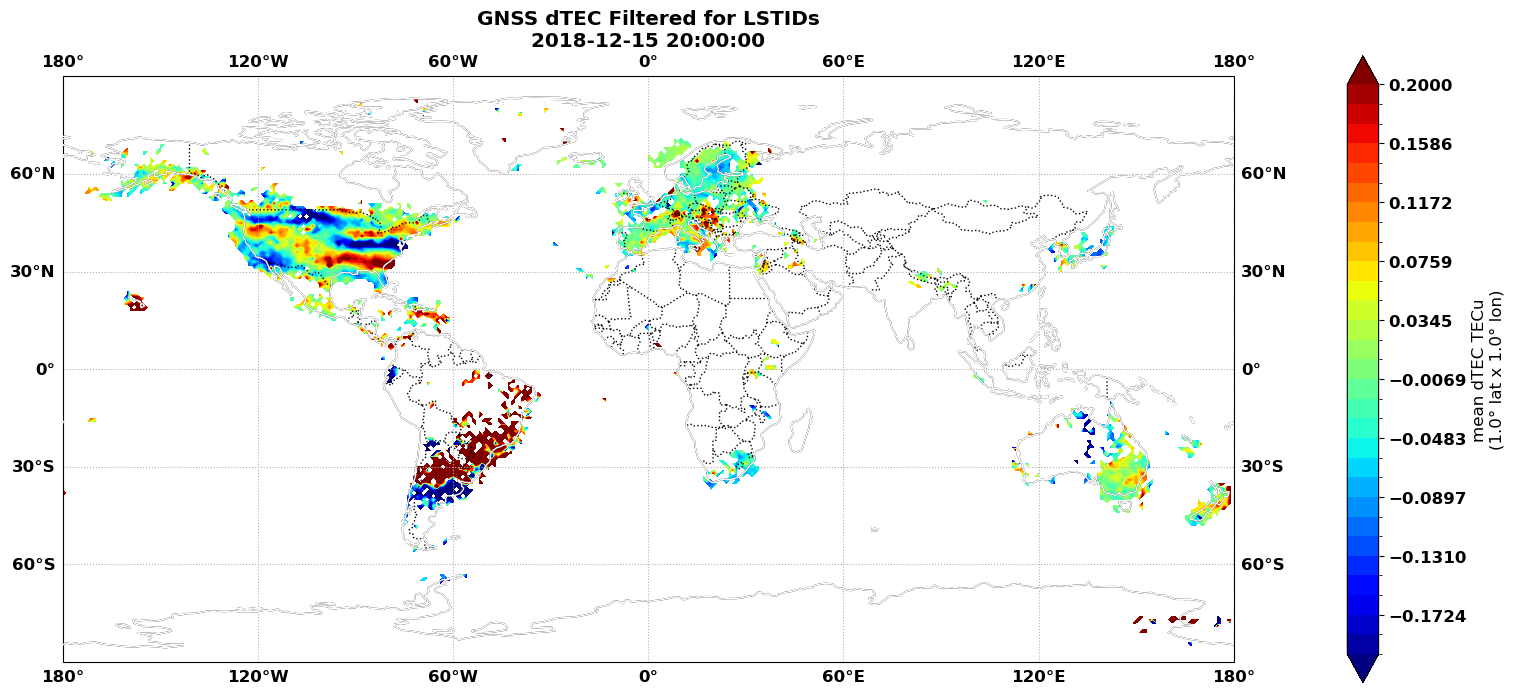

In [13]:
fig     = plt.figure(figsize=(16,10))
ax = hsp.plot_map_ax(fig,subplot=(1,1,1))
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.set_title('')
ax.gridlines(draw_labels=True)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title('GNSS dTEC Filtered for LSTIDs\n'+str(date),fontdict={'weight':'bold','size':'large'})
fig.tight_layout()
plt.show()